Skills used : Deep learning,NLTK,Pandas,

**Problem Statement:**

In this, we have to predict the number of positive and negative reviews based on sentiments by using different classification models.

In [1]:
import pandas as pd
import numpy as np

Error 1: Error tokenizing data. C error: EOF inside string starting at row 17401  
Attempt 1: header = None, delimiter="\t", quoting=csv.QUOTE_NONE, encoding='utf-8'

Attempt 2 : delimiter="\t",
                 engine="python",
                 error_bad_lines=False,  
                 encoding='utf-8'

In [2]:
import csv
df =pd.read_csv('/content/IMDB Dataset.csv',
                delimiter="\t",
                 engine="python",
                 error_bad_lines=False,
                 encoding='utf-8')    #header = None, delimiter="\t", quoting=csv.QUOTE_NONE, encoding='utf-8')

Streaming output truncated to the last 5000 lines.
Skipping line 44830: '	' expected after '"'
Skipping line 44831: '	' expected after '"'
Skipping line 44832: '	' expected after '"'
Skipping line 44833: '	' expected after '"'
Skipping line 44834: '	' expected after '"'
Skipping line 44835: '	' expected after '"'
Skipping line 44836: '	' expected after '"'
Skipping line 44837: '	' expected after '"'
Skipping line 44838: '	' expected after '"'
Skipping line 44839: '	' expected after '"'
Skipping line 44840: '	' expected after '"'
Skipping line 44841: '	' expected after '"'
Skipping line 44842: '	' expected after '"'
Skipping line 44843: '	' expected after '"'
Skipping line 44844: '	' expected after '"'
Skipping line 44845: '	' expected after '"'
Skipping line 44846: '	' expected after '"'
Skipping line 44847: '	' expected after '"'
Skipping line 44848: '	' expected after '"'
Skipping line 44849: '	' expected after '"'
Skipping line 44851: '	' expected after '"'
Skipping line 44852: '	' 

In [3]:
df


,"review,sentiment"
0,This a fantastic movie of three prisoners who ...
1,This was the worst movie I saw at WorldFest an...
2,Protocol is an implausible movie whose only sa...
3,This was probably the worst movie i have ever ...
4,Oh noes one of these attack of the Japanese gh...
...,...
1532,This was a pretty good movie that was overall ...
1533,What a horrible movie. This movie was so out o...
1534,i just saw Dick Tracy and I thought it was ter...
1535,If you like really shocking movies this is for...


In [4]:
#seperating review and sentiment column
df = pd.read_csv('/content/IMDB Dataset.csv',encoding="latin-1")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


**Explonatary Data Analysis**

In [5]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [6]:
df.shape

(50000, 2)

In [7]:
df


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [8]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [9]:
df['sentiment'].value_counts()

positive    25000
negative    25000
Name: sentiment, dtype: int64

In [10]:
df.sentiment.replace("positive", 1, inplace=True)
df.sentiment.replace("negative", 0, inplace=True)

In [52]:
df

,review,sentiment
0,oneoftheotherreviewhamentionthatafterwatchjust...,1
1,awonderlittlproductthefilmtechniquisveriunassu...,1
2,ithoughtthiwaawonderwaytospendtimeonatoohotsum...,1
3,basicthereafamiliwherealittlboyjakethinktherea...,0
4,pettermatteiloveinthetimeofmoneyisavisualstunf...,1
...,...,...
49995,ithoughtthimovididadownrightgoodjobitwasntascr...,1
49996,badplotbaddialogubadactidiotdirecttheannoyporn...,0
49997,iamacatholtaughtinparochielementarischoolbynun...,0
49998,imgotohavetodisagrewiththeprevioucommentandsid...,0


Text(0.5, 1.0, 'Sentiment Distribution')

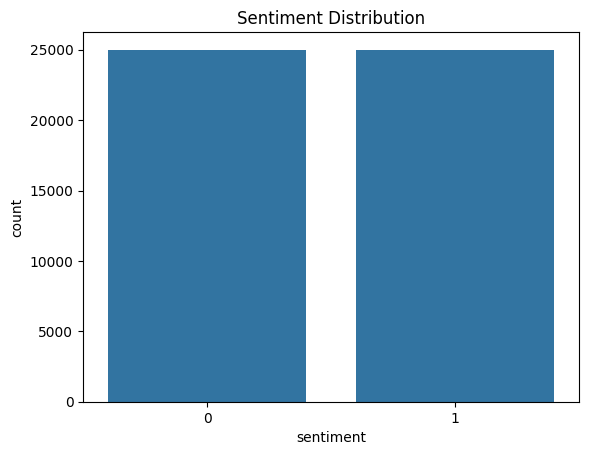

In [53]:
sns.countplot(x='sentiment',data=df)
plt.title('Sentiment Distribution')

dataset is balanced

Text Normalization

#!pip install -q wordcloud ## attempt -1 to solve error LookupError: ********************************************************************
  #Resource stopwords not found.
  #Please use the NLTK Downloader to obtain the resource:

import nltk

nltk.download('all')   this can also work another solution find:::very happy

In [12]:
import nltk
nltk.download("popular")   # attempt - 2 to solve error

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package movie_reviews is already up-to-date!
[nltk_data]    | Downloading package names to /root/nltk_data...
[nltk_data]    |   Package names is already up-to-date!
[nltk_data]    | Do

True

In [13]:
#Load the libraries

import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelBinarizer
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud,STOPWORDS
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize,sent_tokenize
from bs4 import BeautifulSoup
import spacy
import re,string,unicodedata
from nltk.tokenize.toktok import ToktokTokenizer
from nltk.stem import LancasterStemmer,WordNetLemmatizer
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from textblob import TextBlob
from textblob import Word
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

import os
#print(os.listdir("../input"))
import warnings
warnings.filterwarnings('ignore')

**Removing html strips and noise text**

In [15]:
#removing html strips
def strip_html(text):
    soup = BeautifulSoup(text,'html.parser')
    return soup.get_text()

In [16]:
#removing the square brackets
def remove_between_square_brackets(text):
    return re.sub('\[[^]]*\]','',text)

In [17]:
#removing the noisy text
def denoise_text(text):
    text = strip_html(text)
    text = remove_between_square_brackets(text)
    return text

In [18]:
# Using apply function applying on review column
df['review']=df['review'].apply(denoise_text)

**Removing special characters**

In [19]:
#def function for removing special characters
def remove_special_characters(text,remove_digits=True):
    pattern = r'[^a-zA-z0-9\s]'
    text = re.sub(pattern,'',text)
    return text

In [20]:
# Apply function on review column
df['review'] = df['review'].apply(remove_special_characters)

**Text Stemming**

Stemming means convering word in it's original form

In [21]:
#Stemming the text
def simple_stemmer(text):
    ps = nltk.porter.PorterStemmer()
    text = ''.join([ps.stem(word) for word in text.split()])
    return text


In [22]:
#applying function on review coulmn
df['review'] = df['review'].apply(simple_stemmer)

In [54]:
duplicated_count = df.duplicated().sum()
print("Number of duplicate entries: ", duplicated_count)

Number of duplicate entries:  422


In [55]:
df = df.drop_duplicates('review')

In [56]:
stemmer = PorterStemmer()
def stemming(data):
    text = [stemmer.stem(word) for word in data]
    return data

In [57]:
df.review = df['review'].apply(lambda x: stemming(x))

In [59]:
pos_reviews =  df[df.sentiment == 1]
pos_reviews.head()

,review,sentiment
0,oneoftheotherreviewhamentionthatafterwatchjust...,1
1,awonderlittlproductthefilmtechniquisveriunassu...,1
2,ithoughtthiwaawonderwaytospendtimeonatoohotsum...,1
4,pettermatteiloveinthetimeofmoneyisavisualstunf...,1
5,probablmyalltimfavoritmoviastoriofselflesssacr...,1


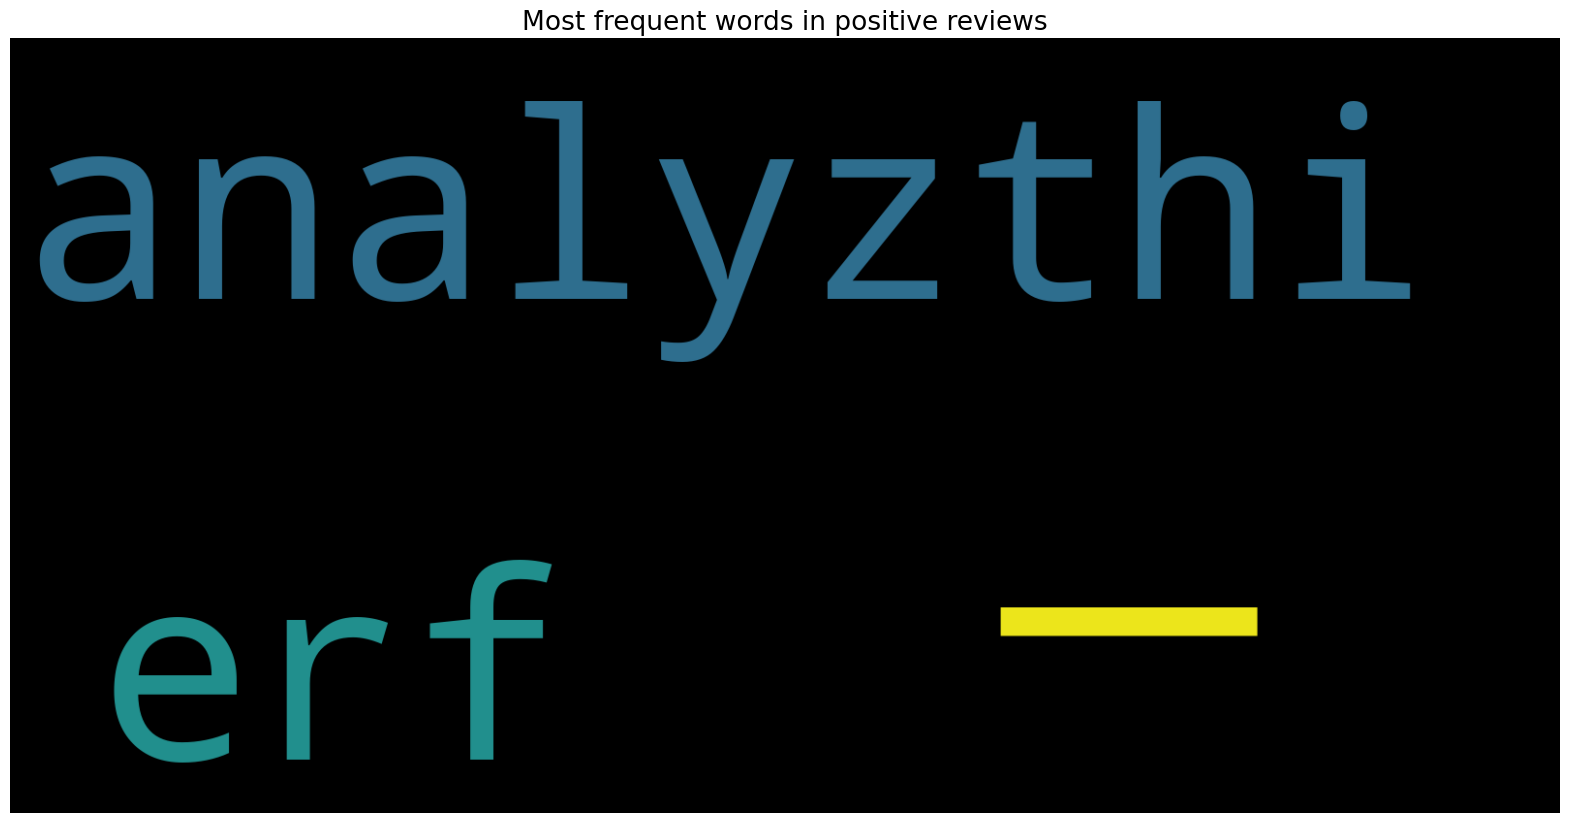

In [60]:
text = ' '.join([word for word in pos_reviews['review']])
plt.figure(figsize=(20,15), facecolor='None')
wordcloud = WordCloud(max_words=500, width=1600, height=800).generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most frequent words in positive reviews', fontsize = 19)
plt.show()

In [61]:
from collections import Counter
count = Counter()
for text in pos_reviews['review'].values:
    for word in text.split():
        count[word] +=1
count.most_common(15)

[('oneoftheotherreviewhamentionthatafterwatchjust1ozepisodyoullbehooktheyarerightasthiisexactliwhathappenwithmethfirstthingthatstruckmeaboutozwaitbrutalandunflinchsceneofviolencwhichsetinrightfromthewordgotrustmethiisnotashowforthefaintheartortimidthishowpullnopunchwithregardtodrugsexorviolencitishardcorintheclassicuseoftheworditiscallozasthatisthenicknamgiventotheoswaldmaximumsecurstatepenitentariitfocusmainlionemeraldcitianexperimentsectionoftheprisonwhereallthecellhaveglassfrontandfaceinwardsoprivaciisnothighontheagendaemcitiishometomanyaryanmuslimgangstalatinochristianitalianirishandmoresoscuffldeathstaredodgidealandshadiagreementareneverfarawayiwouldsaythemainappealoftheshowisduetothefactthatitgoewhereothershowwouldntdareforgetprettipicturpaintformainstreamaudiencforgetcharmforgetromanceozdoesntmessaroundthefirstepisodieversawstruckmeassonastiitwasurrealicouldntsayiwareadiforitbutasiwatchmoreidevelopatastforozandgotaccustomtothehighlevelofgraphicviolencnotjustviolencbutinjusticcro

In [63]:
pos_words = pd.DataFrame(count.most_common(15))
pos_words.columns = ['word', 'count']
pos_words.head()

,word,count
0,oneoftheotherreviewhamentionthatafterwatchjust...,1
1,awonderlittlproductthefilmtechniquisveriunassu...,1
2,ithoughtthiwaawonderwaytospendtimeonatoohotsum...,1
3,pettermatteiloveinthetimeofmoneyisavisualstunf...,1
4,probablmyalltimfavoritmoviastoriofselflesssacr...,1


In [65]:
import plotly.express as px
px.bar(pos_words, x='count', y='word', title='Common words in positive reviews', color = 'word')

**Splitting the Datase**t

In [66]:
X = df['review']
Y = df['sentiment']

**Bags of words model**

It is used to convert text documents to numerical vectors or bag of words.

WHAT IS THE BAG OF WORDS MODEL IN NLP?
The bag of words model is a simple way to convert words to numerical representation in natural language processing. This model is a simple document embedding technique based on word frequency. Conceptually, we think of the whole document as a “bag” of words, rather than a sequence. We represent the document simply by the frequency of each word. Using this technique, we can embed a whole set of documents and feed them into a variety of different machine learning algorithms.

In [68]:
from sklearn.feature_extraction.text import CountVectorizer
vect = CountVectorizer()
X = vect.fit_transform(df['review'])

In [70]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [71]:
print("Size of x_train: ", (x_train.shape))
print("Size of y_train: ", (y_train.shape))
print("Size of x_test: ", (x_test.shape))
print("Size of y_test: ", (y_test.shape))

Size of x_train:  (34704, 51475)
Size of y_train:  (34704,)
Size of x_test:  (14874, 51475)
Size of y_test:  (14874,)


**Labeling the Sentiment data**

In [72]:
#labeling the sentient data
lb=LabelBinarizer()
#transformed sentiment data
sentiment_data=lb.fit_transform(df['sentiment'])
print(sentiment_data.shape)

(49578, 1)


**Modelling the dataset**

In [73]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

**Model 1 : Logistic Regression mode**l

Let us build logistic regression model for both bag of words

**Logistic regression model for trianing dataset**

In [74]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(x_train, y_train)
logreg_pred = logreg.predict(x_test)
logreg_acc = accuracy_score(logreg_pred, y_test)
print("Test accuracy: {:.2f}%".format(logreg_acc*100))

Test accuracy: 49.88%


In [75]:
print(confusion_matrix(y_test, logreg_pred))
print("\n")
print(classification_report(y_test, logreg_pred))

[[   0 7455]
 [   0 7419]]


              precision    recall  f1-score   support

           0       0.00      0.00      0.00      7455
           1       0.50      1.00      0.67      7419

    accuracy                           0.50     14874
   macro avg       0.25      0.50      0.33     14874
weighted avg       0.25      0.50      0.33     14874



**Model 2: Multinomial Naive Bayes for bag of words s**

In [76]:
mnb = MultinomialNB()
mnb.fit(x_train, y_train)
mnb_pred = mnb.predict(x_test)
mnb_acc = accuracy_score(mnb_pred, y_test)
print("Test accuracy: {:.2f}%".format(mnb_acc*100))

Test accuracy: 49.93%


**Print the confusion matrix**

In [77]:
print(confusion_matrix(y_test, mnb_pred))
print("\n")
print(classification_report(y_test, mnb_pred))

[[  12 7443]
 [   5 7414]]


              precision    recall  f1-score   support

           0       0.71      0.00      0.00      7455
           1       0.50      1.00      0.67      7419

    accuracy                           0.50     14874
   macro avg       0.60      0.50      0.33     14874
weighted avg       0.60      0.50      0.33     14874



**Model 3:Linear support vector machines for bag of word**s

In [79]:
from sklearn.svm import LinearSVC
svc = LinearSVC()
svc.fit(x_train, y_train)
svc_pred = svc.predict(x_test)
svc_acc = accuracy_score(svc_pred, y_test)
print("Test accuracy: {:.2f}%".format(svc_acc*100))

Test accuracy: 49.88%


**Plot the confusion matrix**

In [80]:
print(confusion_matrix(y_test, svc_pred))
print("\n")
print(classification_report(y_test, svc_pred))

[[   0 7455]
 [   0 7419]]


              precision    recall  f1-score   support

           0       0.00      0.00      0.00      7455
           1       0.50      1.00      0.67      7419

    accuracy                           0.50     14874
   macro avg       0.25      0.50      0.33     14874
weighted avg       0.25      0.50      0.33     14874



**Model 4 Deciosion Tree**



In [81]:
from sklearn.tree import DecisionTreeClassifier

dct = DecisionTreeClassifier()
dct.fit(x_train, y_train)
dct_pred = svc.predict(x_test)
dct_acc = accuracy_score(svc_pred, y_test)
print("Test accuracy: {:.2f}%".format(dct_acc*100))

Test accuracy: 49.88%


**Plot the Confusion Matrix**

In [83]:
print(confusion_matrix(y_test, dct_pred))
print("\n")
print(classification_report(y_test, dct_pred))

[[   0 7455]
 [   0 7419]]


              precision    recall  f1-score   support

           0       0.00      0.00      0.00      7455
           1       0.50      1.00      0.67      7419

    accuracy                           0.50     14874
   macro avg       0.25      0.50      0.33     14874
weighted avg       0.25      0.50      0.33     14874

